##### Libraries

In [2]:
import pandas as pd
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

##### General parameters and configurations

In [ ]:
data_syntethic = "WELL-data_synthetic_timeseries.csv"
data_dir = "data"
header = ['timestamp', 'P-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP', 'T-JUS-CKP', 'P-JUS-CKGL', 'T-JUS-CKGL', 'QGL']

       
df_data = pd.DataFrame(columns=header)
df_data[['P-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP', 'T-JUS-CKP', 'P-JUS-CKGL', 'T-JUS-CKGL', 'QGL']] = df_data[['P-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP', 'T-JUS-CKP', 'P-JUS-CKGL', 'T-JUS-CKGL', 'QGL']].astype(float)


def save_file_df(df, dir, file):  
    """Save DataFrame to CSV file. If the file already exists, append the data."""
    file_path = os.path.join(dir, file)  
    if not os.path.exists(file_path):
        df.to_csv(file_path, index=False, mode='w', header=True)
    else:
        df.to_csv(file_path, index=False, mode='a', header=False)

#### Functions to generate synthetic time series data with anomalies.

In [ ]:
def generate_mean_jumps(mean_val, change_point_frequency):
    """Generate a time series with mean jumps at specified intervals"""
    # Initialize parameters
    n_samples = 50000
    y = np.zeros(n_samples)
    std_dev = 0.00055  # Initial standard deviation

    # Generate the noise array
    noise = np.zeros(n_samples)
    change_point_counts = int(n_samples/change_point_frequency)
    mean_array =  np.ones(change_point_counts) * mean_val
    change_point = np.random.randint(len(mean_array))  # Randomly select change point     
    mean_array[change_point] += mean_val * 1.0000005
    
    # Calculate noise values for each segment
    for N in range(change_point_counts):
        current_segment_start=change_point_frequency*(N)
        noise[current_segment_start:current_segment_start+change_point_frequency] = np.random.normal(mean_array[N], std_dev, size=change_point_frequency)

    # Generate the AR process
    for t in range(n_samples):
       y[t] = noise[t] 
    
    return y

def generate_timeseries_column(df, start_time):
    """Generate a time series column with random values and timestamps."""

    periods = 50000  # Number of time points
    freq = "5S"  # Frequency: 5 seconds

    # Create time series
    timestamps = pd.date_range(start=start_time, periods=periods, freq=freq)

    # Add to a DataFrame
    df['timestamp']  = timestamps

    return df

#### Call functions for data generation and plot results for verifiation

C:\Users\adrid\AppData\Local\Temp\ipykernel_54636\2994916744.py:32: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  timestamps = pd.date_range(start=start_time, periods=periods, freq=freq)


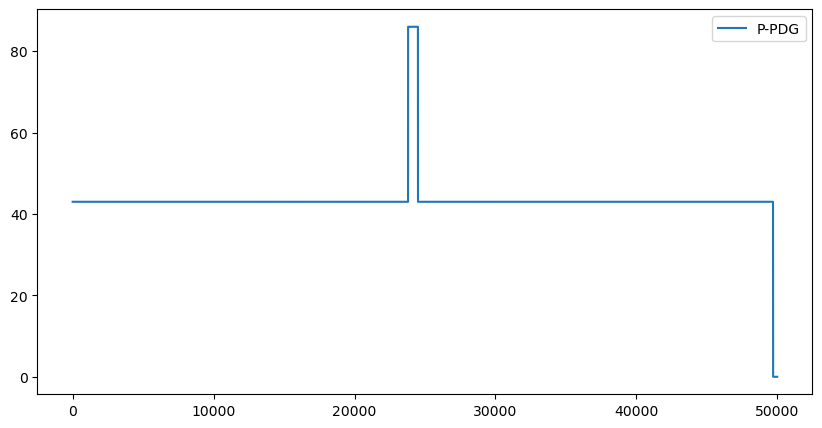

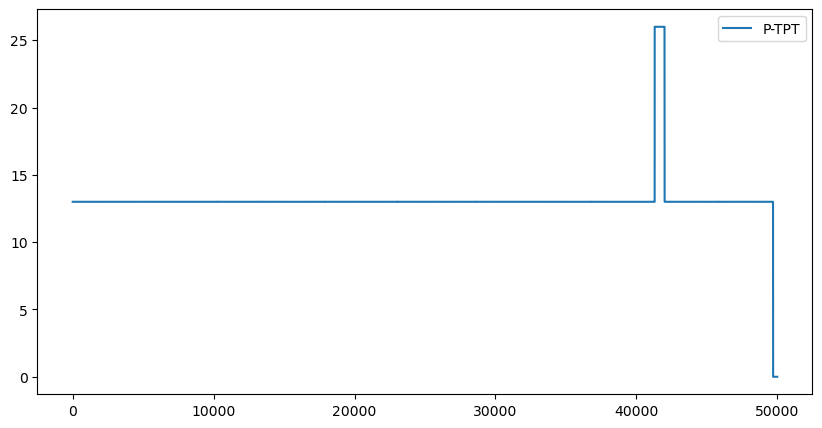

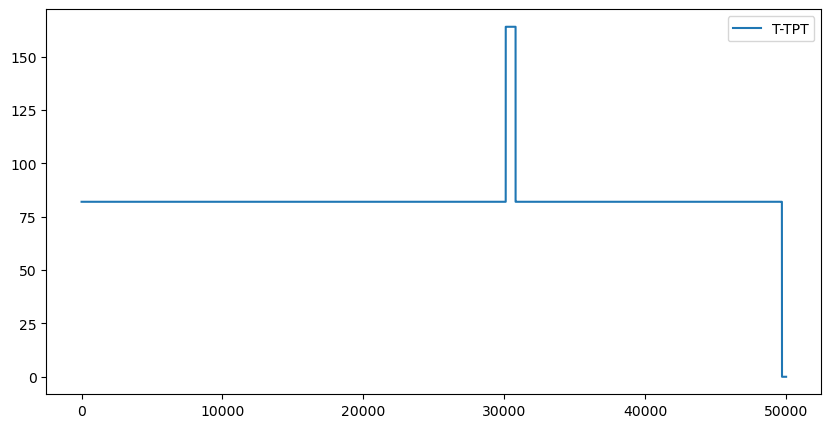

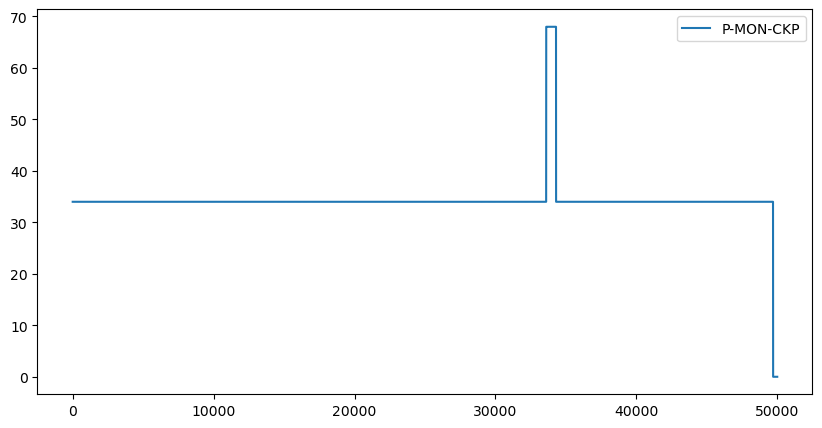

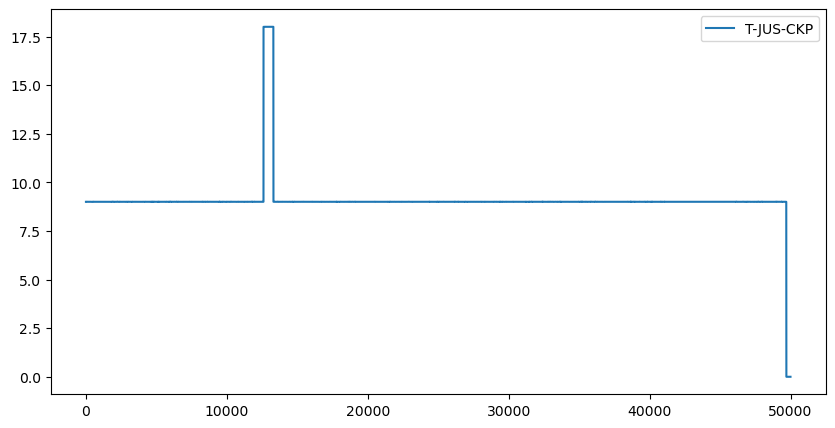

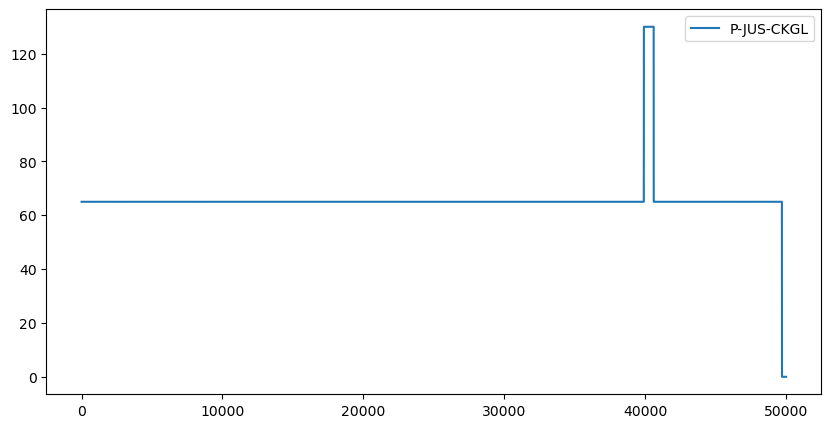

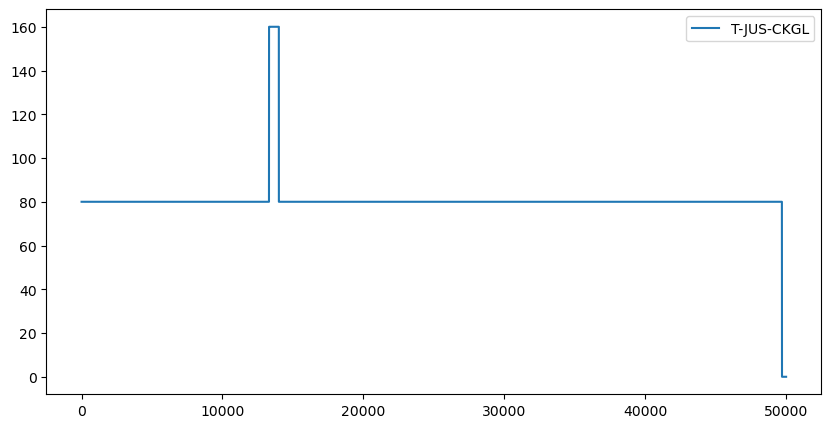

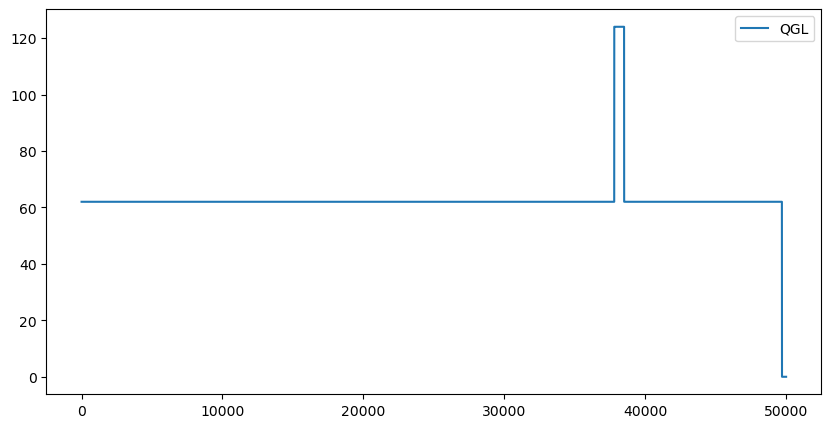

In [11]:

# Call the functions to generate the time series synthetic data and save to CSV. Plot the data for verification
df_data = generate_timeseries_column(df_data, "2025-01-01 00:00:00")

i = 1
for header_name in header[1:]:
    plt.figure(figsize=(10, 5))
    mean_val =  np.random.randint(2, 100)
    y = generate_mean_jumps(mean_val, change_point_frequency=700)
    plt.plot(y, label=header_name)
    df_data[header_name] = y
    i = i + 1
    plt.legend()
    plt.show()

save_file_df(df_data, data_dir, data_syntethic)